In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from pinn import PINN
from network import Network
from optimizer import L_BFGS_B

## Vector Potential Diffusion Equation
$$
\nabla \times \nu(B)(\nabla \times \mathbf{A}) = - \sigma \frac{\partial \mathbf{A}}{\partial t}
$$

## Relation Between Magnetic Flux and Vector Potential
$$
\mathbf{B} = \nabla \times \mathbf{A}
$$

### Expanded in Cartesian Coordinates:
$$
\mathbf{B} =
\begin{vmatrix}
\hat{i} & \hat{j} & \hat{k} \\
\frac{\partial}{\partial x} & \frac{\partial}{\partial y} & \frac{\partial}{\partial z} \\
A_x & A_y & A_z
\end{vmatrix}
$$

Expanding the determinant:
$$
\mathbf{B} =
\left( \frac{\partial A_z}{\partial y} - \frac{\partial A_y}{\partial z} \right) \hat{i} +
\left( \frac{\partial A_x}{\partial z} - \frac{\partial A_z}{\partial x} \right) \hat{j} +
\left( \frac{\partial A_y}{\partial x} - \frac{\partial A_x}{\partial y} \right) \hat{k}
$$

Thus, the components of \( \mathbf{B} \) are:
$$
B_x = \frac{\partial A_z}{\partial y} - \frac{\partial A_y}{\partial z}
$$
$$
B_y = \frac{\partial A_x}{\partial z} - \frac{\partial A_z}{\partial x}
$$
$$
B_z = \frac{\partial A_y}{\partial x} - \frac{\partial A_x}{\partial y}
$$



## Ampère's Circuital Law (For Boundary)
$$
\oint \nu(B) \mathbf{B_t} \cdot d\mathbf{l} =  I
$$

## Current Density Using Vector Potential
$$
\mathbf{J} = - \nabla \frac{1}{\mu(H)} \nabla \mathbf{A}= -\nabla \nu(B) \nabla \mathbf{A}
$$




# Non-linear problem

- The following conditions and domain are imposed on this problem:
  - Absence of material motion ($v=0$).
  - Homogeneous magnetic material.

- Equation for Inside the Domain:
$$
\frac{\partial}{\partial x}(\nu(B) \frac{\partial A_z}{\partial x})+ \frac{\partial}{\partial y}(\nu(B) \frac{\partial A_z}{\partial y})  = \sigma \frac{\partial {A_z}}{\partial t}.
$$

$$
\mathbf{B} =
\left( \frac{\partial A_z}{\partial y}  \right) \hat{i} +
\left(  - \frac{\partial A_z}{\partial x} \right) \hat{j}
$$

- The reluctivity 𝜈 as a function of the magnetic flux density 𝐵 for a nonlinear, reversible material (Saturation model)):

$$
\nu(B) = \frac{\mu^{-1}}{1 - b \mu^{-1} |B|}
$$

- Equations for Boundary:
$$
A_z = Constant
$$

$$
-\int_l \nu(B_{1x}) B_{1x} dx - \int_l \nu(B_{2y}) B_{2y} dy + \int_l \nu(B_{3x}) B_{3x} dx + \int_l \nu(B_{4y}) B_{4y} dy = I_0
$$
$$
( B_x = \frac{\partial A_z}{\partial y} )
( B_y = -\frac{\partial A_z}{\partial x}  )
$$

$$
-\int_{l_1} \frac{a}{1 - b |\frac{\partial A_z}{\partial y}|} \frac{\partial A_z}{\partial y} dx - \int_{l_2} \frac{a}{1 - b |\frac{\partial A_z}{\partial x}|} \frac{\partial A_z}{\partial x} dy + \int_{l_3} \frac{a}{1 - b |\frac{\partial A_z}{\partial y}|} \frac{\partial A_z}{\partial y} dx + \int_{l_4} \frac{a}{1 - b |\frac{\partial A_z}{\partial x}|} \frac{\partial A_z}{\partial x} dy = I_0
$$

# Training Data Preparation

In [3]:
# Number of training and test samples
baseNmunber = 30
timeNmunber = 30
num_train_samples_pde = timeNmunber * baseNmunber * baseNmunber
num_train_samples = timeNmunber * baseNmunber
num_train_ini = baseNmunber * baseNmunber

# Time and space domain bounds
f = 1
omega = 2 * np.pi * f
mu_0 = 4 * np.pi * 1e-7  # Permeability of free space (H/m)
mu = 1  # Relative permeability (minimum) 1
b = 1e-7 / (mu_0 * mu)
sigma = 2 * 1e6  # Electrical conductivity of copper (S/m) 2 * 1e6
D = mu_0 * mu * sigma
delta = np.sqrt(2/(D*omega))
t_f = 1 * 0.3/f               # 0.3/f
z_ini, z_f =  0, 1  # Spatial domain for z
y_ini, y_f = 0 , 1 #-0.5, 0.5       # Spatial domain for y
I = 10**7#1 / (mu * mu_0)
Az = 10

print('f = ',f, ' Hz')
print('omega = ',omega, ' Hz')
print('sigma = ',sigma, ' S/m')
print('mu = ', mu, 'mu_0 H/m')
print('Diffusion coefficient (mu_0 * mu * sigma) = ',D, ' m2/s')
print('Skin depth (sqrt(2/(D*omega))) = ',delta, ' m')
print('t_diff (L^2 / D) =', ((z_f-z_ini)**2) * D,' s')

print('Time = ',t_f, ' s')

print('z_ini = ', z_ini, ' m')
print('z_f = ',z_f, ' m')
print('z = ',z_f - z_ini, ' m')

print('y_ini = ',y_ini, ' m')
print('y_f = ',y_f, ' m')
print('y = ',y_f - y_ini, ' m') 

print('I = ',I, ' A')

print('num_train_samples_pde = ',num_train_samples_pde)
print('num_train_samples_bound = ',num_train_samples)
print('num_train_samples_ini = ',num_train_ini)


# Create training inputs

# ## Interior Points (for solving PDEs within the domain)
# tzy_pde = np.random.rand(num_train_samples_pde, 3)
# tzy_pde[..., 0] = t_f * tzy_pde[..., 0]                             # t ∈ [0, t_f]
# tzy_pde[..., 1] = (z_f - z_ini) * tzy_pde[..., 1] + z_ini           # z ∈ [z_ini, z_f]
# tzy_pde[..., 2] = (y_f - y_ini) * tzy_pde[..., 2] + y_ini           # y ∈ [y_ini, y_f]


# ## Initial Condition (at t = 0)
# tzy_ini = np.random.rand(num_train_samples, 3)
# tzy_ini[..., 0] = 0                                                 # t = 0
# tzy_ini[..., 1] = (z_f - z_ini) * tzy_ini[..., 1] + z_ini           # x ∈ [x_ini, x_f]
# tzy_ini[..., 2] = (y_f - y_ini) * tzy_ini[..., 2] + y_ini           # y ∈ [y_ini, y_f]

# ## Boundary Conditions
# # Bottom and Top boundaries (y = y_ini and y = y_f)
# tzy_y_b = np.random.rand(num_train_samples, 3)
# tzy_y_b[:, 0] = t_f * tzy_y_b[:, 0]  # t ∈ [0, t_f]
# tzy_y_b[:, 1] = (z_f - z_ini) * tzy_y_b[:, 1] + z_ini  # z ∈ [z_ini, z_f]
# tzy_y_b[:, 2] = y_ini  # y = y_ini

# tzy_y_t = np.random.rand(num_train_samples, 3)
# tzy_y_t[:, 0] = t_f * tzy_y_t[:, 0]  # t ∈ [0, t_f]
# tzy_y_t[:, 1] = (z_f - z_ini) * tzy_y_t[:, 1] + z_ini  # z ∈ [z_ini, z_f]
# tzy_y_t[:, 2] = y_f  # y = y_f

# # Left and Right boundaries (z = z_ini and z = z_f)
# tzy_z_l = np.random.rand(num_train_samples, 3)
# tzy_z_l[:, 0] = t_f * tzy_z_l[:, 0]  # t ∈ [0, t_f]
# tzy_z_l[:, 1] = z_ini  # z = z_ini
# tzy_z_l[:, 2] = (y_f - y_ini) * tzy_z_l[:, 2] + y_ini  # y ∈ [y_ini, y_f]

# tzy_z_r = np.random.rand(num_train_samples, 3)
# tzy_z_r[:, 0] = t_f * tzy_z_r[:, 0]  # t ∈ [0, t_f]
# tzy_z_r[:, 1] = z_f  # z = z_f
# tzy_z_r[:, 2] = (y_f - y_ini) * tzy_z_r[:, 2] + y_ini  # y ∈ [y_ini, y_f]

# Define the number of points in each dimension
num_t_points = timeNmunber  # Number of time samples
num_z_points = baseNmunber  # Number of x samples
num_y_points = baseNmunber  # Number of y samples

# Generate structured points with fixed spacing
t_values = np.linspace(0, t_f, num_t_points)  # Time points
# t_values = np.logspace(0, np.log10(t_f), num_t_points) 
# t_values = np.logspace(0, np.log10(t_f), num_t_points)

# alpha = 1.3  
# t_values = t_f * (np.arange(num_t_points) / (num_t_points - 1))**alpha  # Non-uniform spacing

z_values = np.linspace(z_ini, z_f, num_z_points)  # X points
y_values = np.linspace(y_ini, y_f, num_y_points)  # Y points

dt = (t_f - 0) / (num_t_points - 1)
dx = (z_f - z_ini) / (num_z_points - 1)
dy = (y_f - y_ini) / (num_y_points - 1)

dr = ( dx + dy ) / 2
num_r_points = int(( num_z_points + num_y_points ) / 2)

# Bottom boundary (y = y_ini)
tzy_y_b_int = np.array([[t, z, y_ini] for t in t_values for z in z_values])
# Top boundary (y = y_f)
tzy_y_t_int = np.array([[t, z, y_f] for t in t_values for z in z_values])
# Left boundary (x = x_ini)
tzy_z_l_int = np.array([[t, z_ini, y] for t in t_values for y in y_values])
# Right boundary (x = x_f)
tzy_z_r_int = np.array([[t, z_f, y] for t in t_values for y in y_values])

# # Generate structured points with fixed spacing

# z_temp = np.linspace(-2, 2, num_z_points)
# z_values = z_ini + (z_f - z_ini) * (np.tanh(z_temp) + 1) / 2

# y_temp = np.linspace(-2, 2, num_y_points)
# y_values = y_ini + (y_f - y_ini) * (np.tanh(y_temp) + 1) / 2

# z = np.linspace(0, np.pi, num_z_points)
# z_values = z_ini + (z_f - z_ini) * (1 - np.cos(z)) / 2

# y = np.linspace(0, np.pi, num_y_points)
# y_values = y_ini + (y_f - y_ini) * (1 - np.cos(y)) / 2

# z_temp = np.linspace(-2, 2, num_z_points)
# z_values = z_ini + (z_f - z_ini) * (1 / (1 + np.exp(-z_temp)) )

# y_temp = np.linspace(-2, 2, num_z_points)
# y_values = y_ini + (y_f - y_ini) * (1 / (1 + np.exp(-y_temp)) )

# Bottom boundary (y = y_ini)
tzy_y_b = np.array([[t, z, y_ini] for t in t_values for z in z_values])
# Top boundary (y = y_f)
tzy_y_t = np.array([[t, z, y_f] for t in t_values for z in z_values])
# Left boundary (x = x_ini)
tzy_z_l = np.array([[t, z_ini, y] for t in t_values for y in y_values])
# Right boundary (x = x_f)
tzy_z_r = np.array([[t, z_f, y] for t in t_values for y in y_values])

tzy_ini= np.array([[0, z, y] for z in z_values for y in y_values])

tzy_pde = np.array([[t, z, y] for t in t_values[1:-1] for z in z_values[1:-1] for y in y_values[1:-1]])


def u0(tzy,omega):
    """
    Initial wave form based on the time component.
    Args:
        tzy: A tensor containing variables (t, z, y) with shape [batch_size, 3], where
             t is time, z is the z-coordinate, and y is the y-coordinate.
             This is expected to be a tf.Tensor of shape (batch_size, 3).      
    Returns:
        u(t, z, y) as tf.Tensor, where the value is based on a sine function of time (t).
    """
    # Extracting the time component (t) from the input tensor
    t = tzy[..., 0, None]  # Get all values in the first column (time), adding an extra dimension
    # The other components, z and y, are extracted but not used in the current wave function
    x = tzy[..., 1, None]  # Get all values in the second column (z), adding an extra dimension
    y = tzy[..., 2, None]  # Get all values in the third column (y), adding an extra dimension
    
    # Return the sine wave based on time 't'
    return tf.cos(omega * t)/tf.cos(omega * t)   # (x**2*(2-x) *  y**2*(2-y))

# Create training outputs
u_pde = np.zeros((len(tzy_pde), 1))  # Placeholder for PDE (interior) points outputs

# Left boundary (z = z_ini) values for the solution u(t, z, y)
u_z_left = np.zeros((num_train_samples, 1)) #u0(tf.constant(tzy_z_l[:num_train_samples, :]), omega).numpy() #
# Right boundary (z = z_f) values for the solution u(t, z, y)
u_z_right = np.zeros((num_train_samples, 1)) #u0(tf.constant(tzy_z_l[:num_train_samples, :]), omega).numpy() #np.zeros((num_train_samples, 1)) 
# Bottom boundary (y = y_ini) values for the solution u(t, z, y)
u_y_bottom = np.zeros((num_train_samples, 1)) #
# Top boundary (y = y_f) values for the solution u(t, z, y)
u_y_top = np.zeros((num_train_samples, 1))   

# Initial condition at t = 0 for the solution u(t, z, y)
u_ini = np.zeros((num_train_ini, 1))   # Placeholder for initial condition values

# u_x_left = u0(tf.constant(txy_x_l[:num_train_samples, :]), omega).numpy()
du_z_left = np.zeros((num_train_samples, 1)) 
# Right boundary (z = x_f) values for the solution u(t, z, y)
du_z_right = np.zeros((num_train_samples, 1)) 
# Bottom boundary (y = y_ini) values for the solution u(t, z, y)
du_y_bottom = np.zeros((num_train_samples, 1)) 
# Top boundary (y = y_f) values for the solution u(t, z, y)
du_y_top = np.zeros((num_train_samples, 1)) 

# Combine inputs for visualization
x_train = [tzy_pde, tzy_ini, tzy_y_b   , tzy_y_t, tzy_z_l , tzy_z_r  , tzy_y_b_int, tzy_y_t_int, tzy_z_l_int, tzy_z_r_int]
y_train = [u_pde  , u_ini  , u_y_bottom, u_y_top, u_z_left, u_z_right, du_y_bottom, du_y_top   , du_z_left  , du_z_right 
           , u_y_bottom + Az, u_y_top + Az, u_z_left + Az, u_z_right + Az]

names = ['PDE Points', 'Initial Points', 'Y Boundaries', 'Z Boundaries']

f =  1  Hz
omega =  6.283185307179586  Hz
sigma =  2000000.0  S/m
mu =  1 mu_0 H/m
Diffusion coefficient (mu_0 * mu * sigma) =  2.5132741228718345  m2/s
Skin depth (sqrt(2/(D*omega))) =  0.3558812717085885  m
t_diff (L^2 / D) = 2.5132741228718345  s
Time =  0.3  s
z_ini =  0  m
z_f =  1  m
z =  1  m
y_ini =  0  m
y_f =  1  m
y =  1  m
I =  10000000  A
num_train_samples_pde =  27000
num_train_samples_bound =  900
num_train_samples_ini =  900


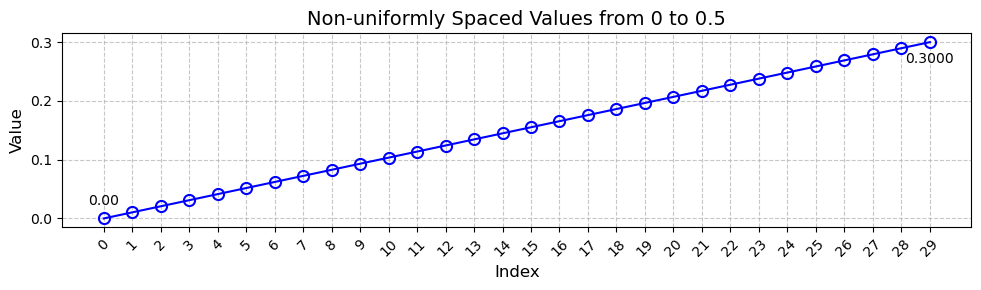

In [4]:
# Create the plot
plt.figure(figsize=(10, 3))
# Plot with both lines and markers
plt.plot(t_values, 'bo-', markersize=8, linewidth=1.5, 
         markerfacecolor='none', markeredgewidth=1.5)
# Add plot decorations
plt.title("Non-uniformly Spaced Values from 0 to 0.5", fontsize=14)
plt.xlabel("Index", fontsize=12)
plt.ylabel("Value", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.xticks(range(len(t_values)), rotation=45)
# Add value annotations for first and last points
plt.annotate(f'{t_values[0]:.2f}', (0, t_values[0]), 
             textcoords="offset points", xytext=(0, 10), ha='center')
plt.annotate(f'{t_values[-1]:.4f}', (len(t_values) - 1, t_values[-1]), 
             textcoords="offset points", xytext=(0, -15), ha='center')
# Adjust layout for better spacing
plt.tight_layout()
plt.show()

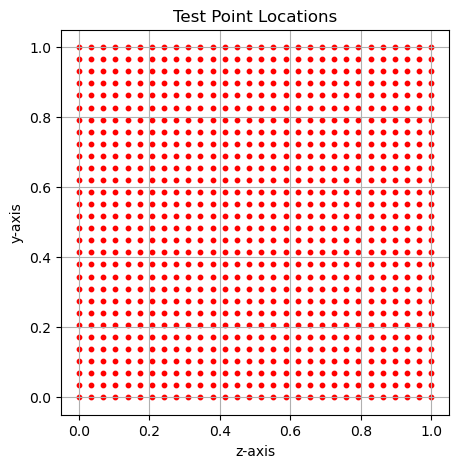

In [5]:
z, y = np.meshgrid(z_values, y_values)
# Flatten meshgrid for scatter plot
z_points = z.flatten()
y_points = y.flatten()
# Plot the scatter points
plt.figure(figsize=(5, 5))
plt.scatter(z_points, y_points, c="red", s=10, label="Locations")  # Adjust s (size) if needed
plt.xlabel("z-axis")
plt.ylabel("y-axis")
plt.title("Test Point Locations")
plt.grid(True)
plt.show()

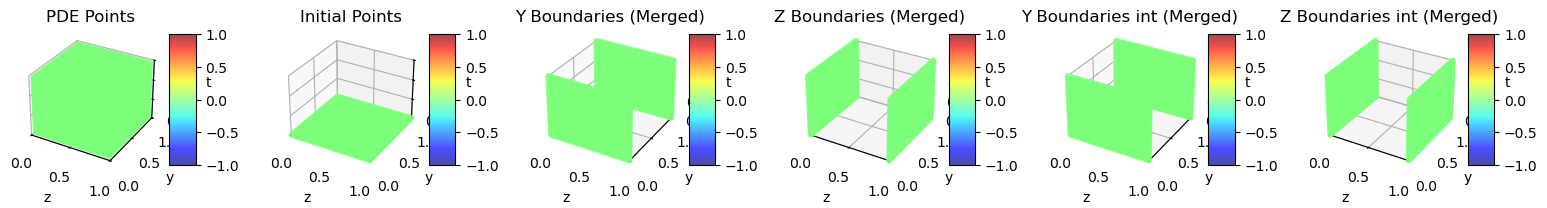

In [6]:
# Merge u_z_left and u_z_right
u_z_combined = np.concatenate([u_z_left, u_z_right], axis=0)
du_z_combined = np.concatenate([du_z_left, du_z_right], axis=0)

# Merge u_y_bottom and u_y_top
u_y_combined = np.concatenate([u_y_bottom, u_y_top], axis=0)
du_y_combined = np.concatenate([du_y_bottom, du_y_top], axis=0)

# Combine the training points for boundaries (Z and Y)
tzy_z_combined = np.concatenate([tzy_z_l[:, :], tzy_z_r[:, :]], axis=0)
tzy_y_combined = np.concatenate([tzy_y_b[:, :], tzy_y_t[:, :]], axis=0)

tzy_z_combined_int = np.concatenate([tzy_z_l_int[:, :], tzy_z_r_int[:, :]], axis=0)
tzy_y_combined_int = np.concatenate([tzy_y_b_int[:, :], tzy_y_t_int[:, :]], axis=0)

# Create a list of outputs for plotting
output_values_combined = [u_pde, u_ini, u_y_combined, u_z_combined, du_y_combined, du_z_combined]
names_combined = ['PDE Points', 'Initial Points', 'Y Boundaries (Merged)', 'Z Boundaries (Merged)',
                   'Y Boundaries int (Merged)', 'Z Boundaries int (Merged)']

# Visualization of training samples with adjusted figure size
fig = plt.figure(figsize=(16, 12))  # Increase the figure size for better spacing

# Iterate through each plot section (name, points, and corresponding output)
for idx, (name, points, output) in enumerate(zip(names_combined, 
                                                  [tzy_pde, tzy_ini, tzy_y_combined, tzy_z_combined,
                                                    tzy_y_combined_int, tzy_z_combined_int], 
                                                  output_values_combined)):
    ax = fig.add_subplot(1, 6, idx + 1, projection='3d')
    
    # Scatter plot with color based on the corresponding output value
    scatter = ax.scatter(points[..., 1], points[..., 2], points[..., 0], c=output.squeeze(), s=10, alpha=0.7, cmap='jet')
    
    # Set the color scale limits between 0 and 1
    scatter.set_clim(-1, 1)
    
    # Titles and axis labels
    ax.set_title(name)
    ax.set_xlabel('z')
    ax.set_ylabel('y')
    ax.set_zlabel('t')
    
    # Set fixed limits for all plots
    ax.set_xlim(z_ini, z_f)
    ax.set_ylim(y_ini, y_f)
    ax.set_zlim(0, t_f)
    
    # Add color bar for reference
    fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)

# Adjust layout with tighter spacing
plt.tight_layout( pad = 3.0 )  # Increase padding for better spacing between subplots

# Display the plot
plt.show()

# Creating and Training the PINN Model with L-BFGS-B Optimization

In [7]:
# Build and summarize the core neural network model
network = Network.build()  # Instantiate the core network model using the `build` method from the Network class
network.summary()  # Print the summary of the network architecture to inspect the model's layers and parameters

# Build the Physics-Informed Neural Network (PINN) model
pinn = PINN(network, D, b = b).build()  # Create the PINN model by passing the core network into the PINN class and building it

# Set up and train the PINN model using L-BFGS optimization
lbfgs = L_BFGS_B(model = pinn, x_train = x_train, y_train = y_train , dr = dr, mu = mu * mu_0, I = I, baseNmunber = baseNmunber, timeNmunber = timeNmunber, b = b)  # Initialize the L-BFGS-B optimizer with the PINN model and training data
lbfgs.fit()  # Fit the model using the L-BFGS-B optimization method to minimize the loss

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 3)]          0           []                               
                                                                                                  
 dense (Dense)                  (None, 48)           192         ['input_1[0][0]']                
                                                                                                  
 dense_1 (Dense)                (None, 48)           2352        ['dense[0][0]']                  
                                                                                                  
 dense_2 (Dense)                (None, 48)           2352        ['dense_1[0][0]']                
                                                                                              

L-BFGS-B Optimization Progress:   0%|          | 0/35000 [00:00<?, ?iteration/s]

Optimizer: L-BFGS-B (maxiter=35000)


L-BFGS-B Optimization Progress:  37%|███▋      | 12956/35000 [7:06:25<12:05:33,  1.97s/iteration, loss=0.0123, lossPde=0.00308, lossBoun=0.00918, loss_int=1.99e-5]


# Predicting $u(t,r)$ distribution

In [8]:
# Save the relevant data to a .npz file
file_name = "Az_PINN_Nonlinear_200.npz"
file_name_J = "Jz_PINN_Nonlinear_200.npz"
FEM_path = "Az_FEM_Nonlinear_200.xlsx"
FEM_B_path = "B_FEM_Nonlinear_200.xlsx"
# Generate test points meshgrid
num_test_samples = 200
FEM_test_samples = 200

In [9]:
t_flat = np.linspace(0, t_f, num_test_samples)
z_flat = np.linspace(z_ini, z_f, num_test_samples)
y_flat = np.linspace(y_ini, y_f, num_test_samples)
z, y = np.meshgrid(z_flat, y_flat)

# Flatten meshgrid for scatter plot
z_points = z.flatten()
y_points = y.flatten()

# # Plot the scatter points
# plt.figure(figsize=(6, 6))
# plt.scatter(z_points, y_points, c="red", s=1, label="Locations")  # Adjust s (size) if needed
# plt.xlabel("z-axis")
# plt.ylabel("y-axis")
# plt.title("Test Point Locations")
# plt.grid(True)
# plt.show()

# Define time intervals
time_intervals = np.linspace(t_f/30, t_f, 30)  # 10 intervals from 0 to t_f

# Store results for visualization
predictions = []

for t in time_intervals:
    tzy = np.stack([
        np.ones((num_test_samples**2,)) * t,  # Time t
        z.flatten(),  # Flattened z-axis values
        y.flatten()   # Flattened y-axis values
    ], axis=-1)
    
    u_t = network.predict(tzy, batch_size=num_test_samples)  # Predict in batches for efficiency
    predictions.append(u_t.reshape(z.shape))  # Reshape to match z shape



np.savez(file_name, time_intervals=time_intervals, z=z, y=y, predictions=predictions)

200/200 [==============================] - 0s 1ms/step


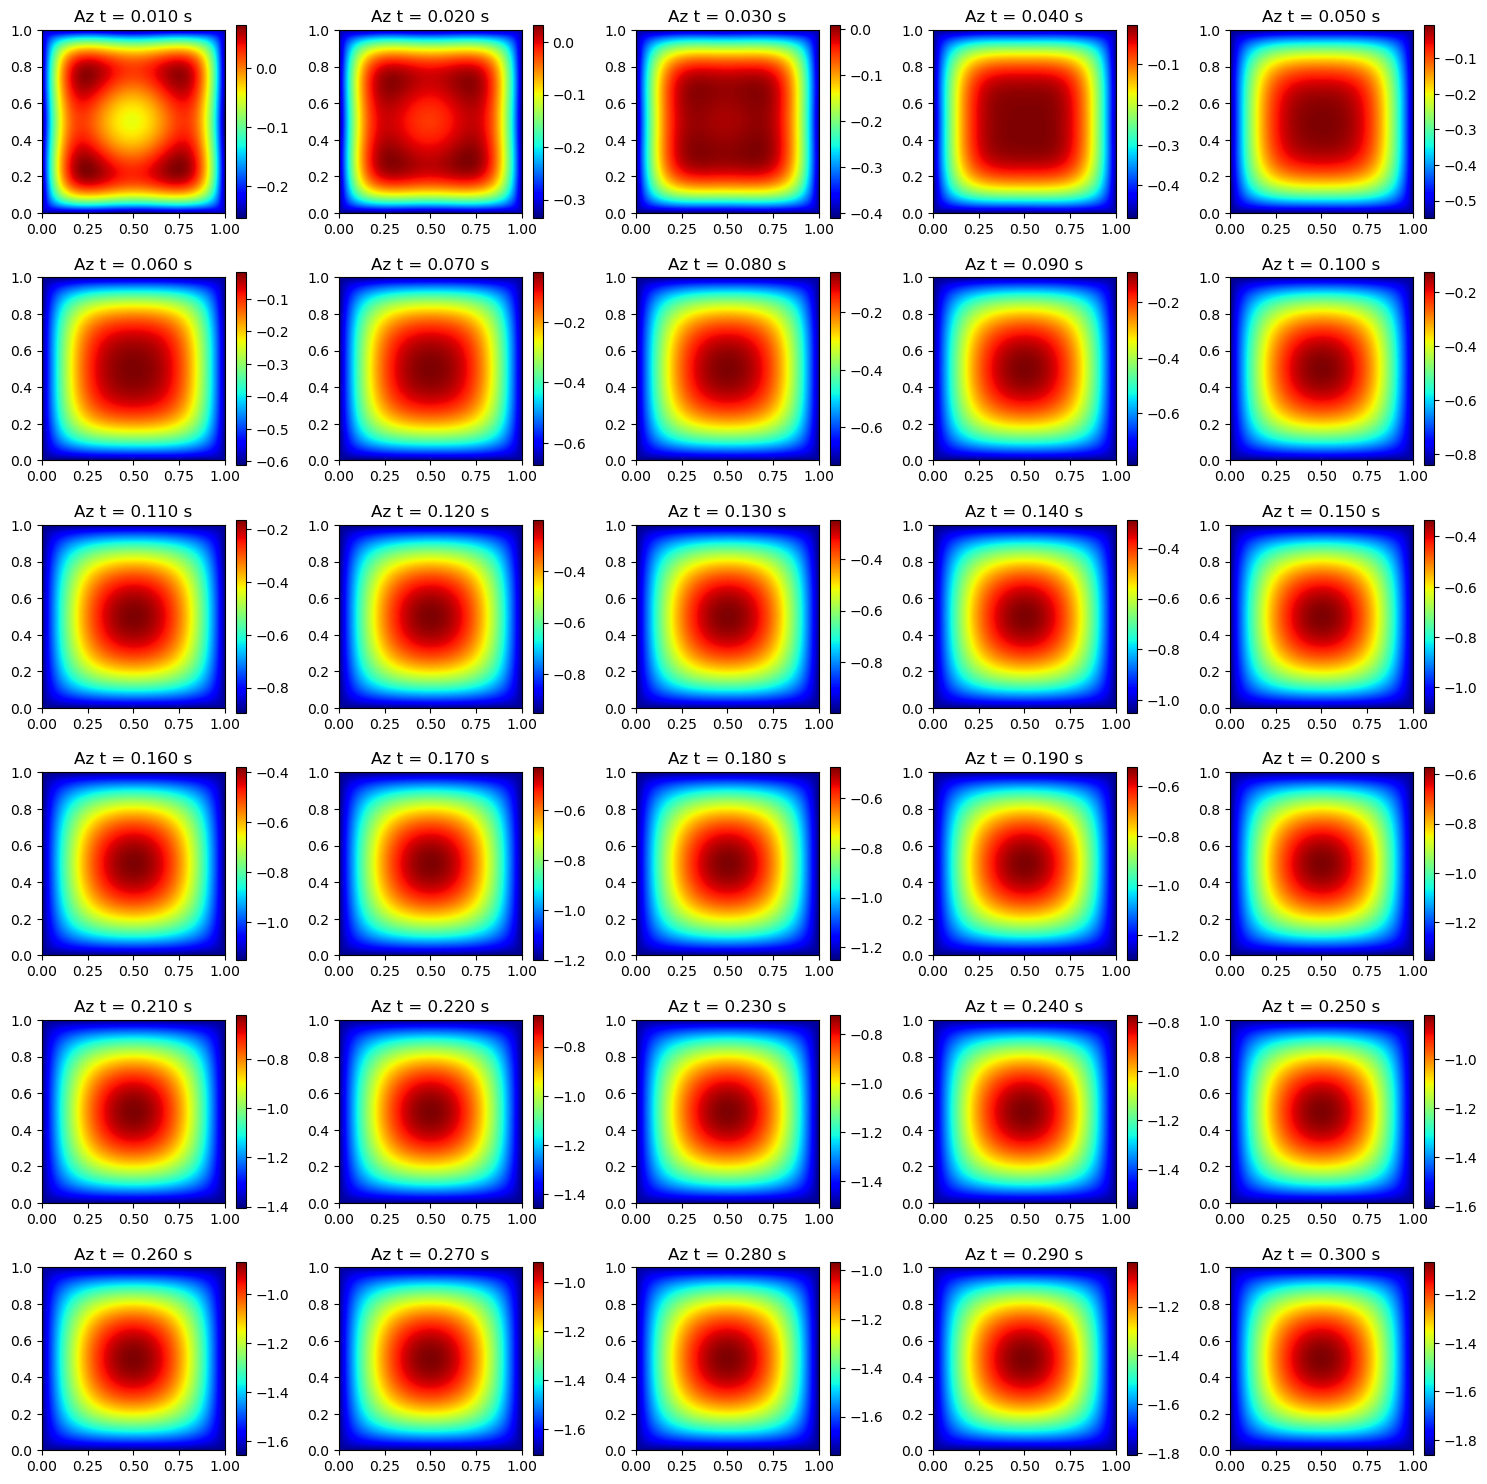

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load test data
# Load the saved data
data = np.load(file_name)

# Extract the individual arrays
time_intervals = data["time_intervals"]
x = data["z"]
y = data["y"]
predictions = data["predictions"]

# Determine global color limits
vmin = np.min(predictions)
vmax = np.max(predictions)

# Plot results using subplots
fig, axes = plt.subplots(6, 5, figsize=(15, 15))  # 2 rows, 5 columns
axes = axes.flatten()

for i, ax in enumerate(axes):
    im = ax.imshow(predictions[i], extent=[y.min(), y.max(), x.min(), x.max()],origin='lower', cmap='jet') #,vmin=-.1,vmax=.3
    ax.set_title(f'Az t = {time_intervals[i]:.3f}'+' s')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


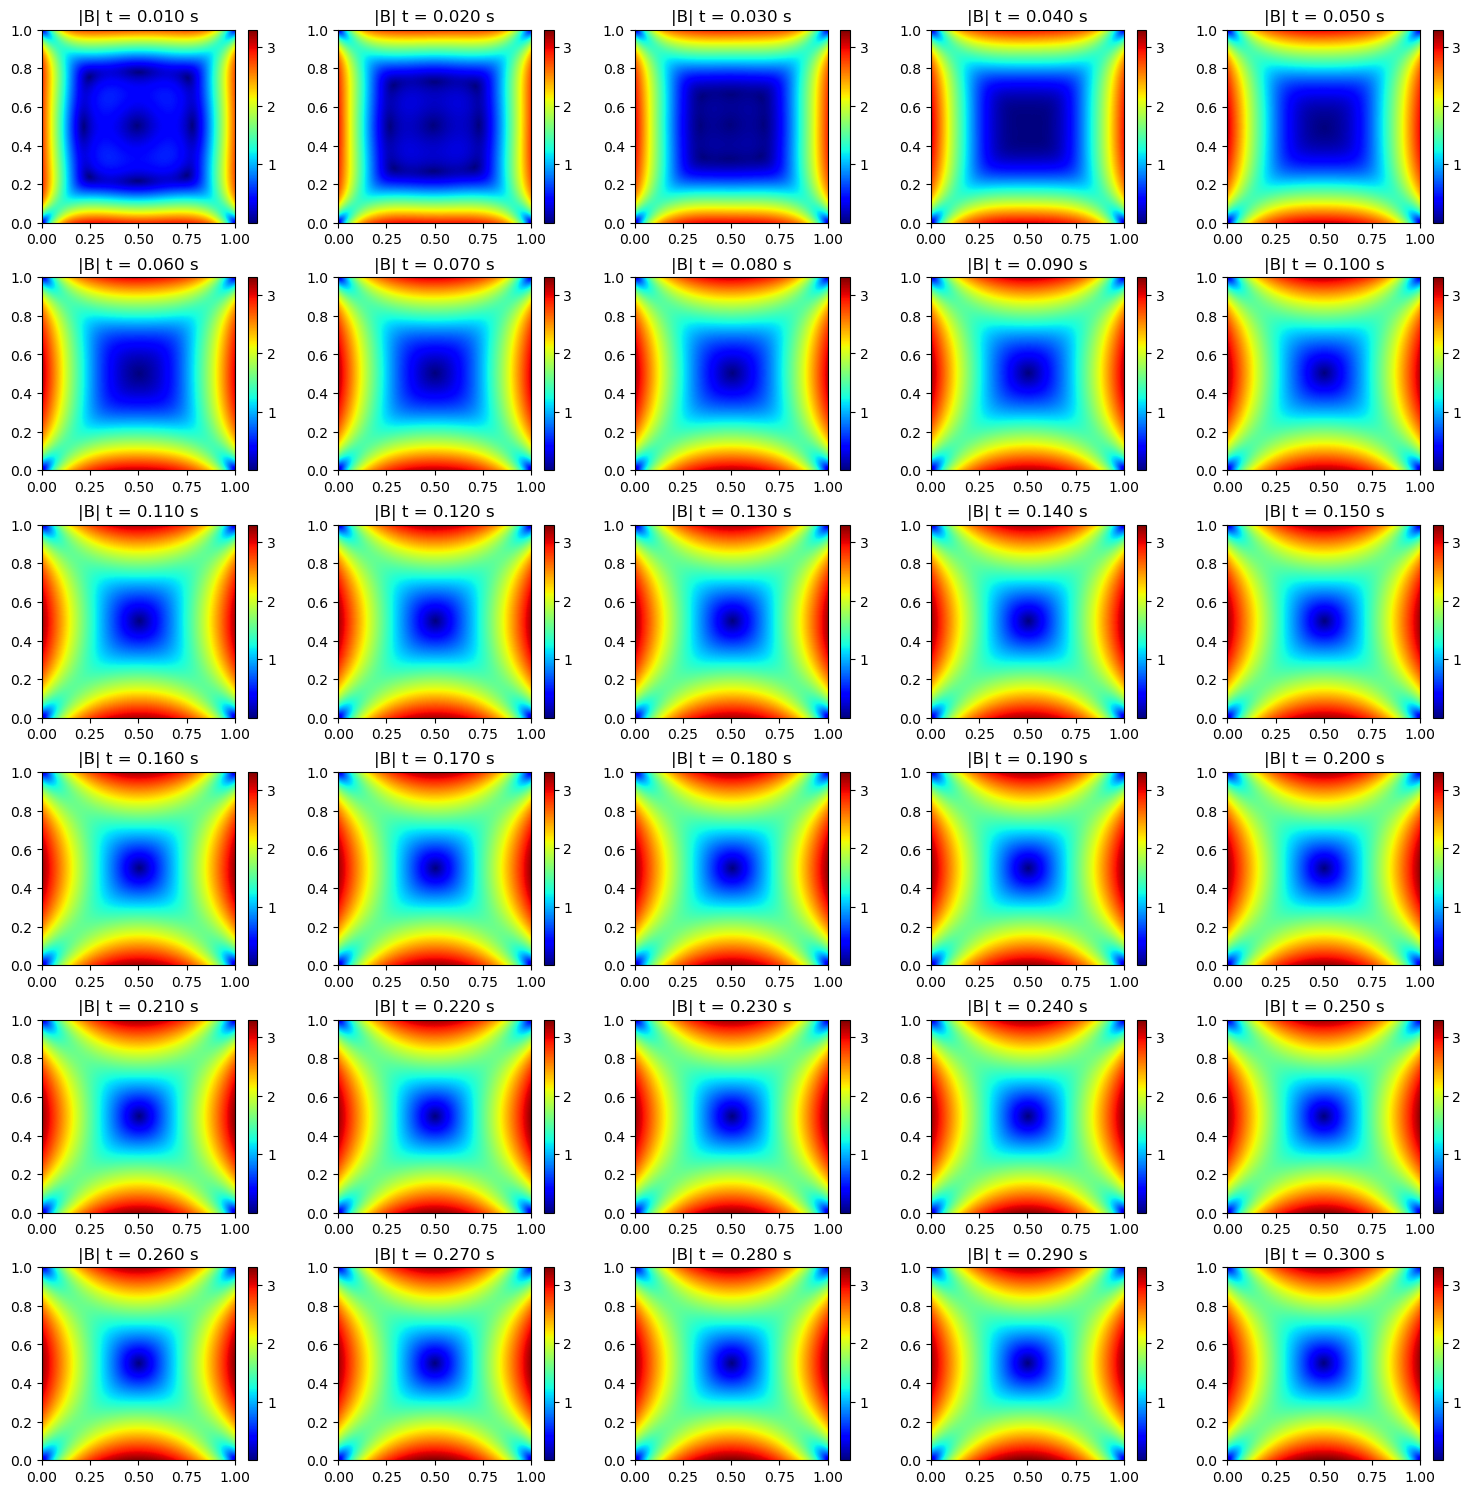

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load test data
data = np.load(file_name)

# Extract the individual arrays
time_intervals = data["time_intervals"]
x = data["z"]  # Assuming 'z' is actually 'x' based on your description
y = data["y"]
predictions = data["predictions"]

dx = x[0, 1] - x[0, 0]
dy = y[1, 0] - y[0, 0]

# Calculate the gradient of Az to get Bx and By
Bx = np.gradient(predictions, axis=2)/dy  # Gradient along y-axis (∂Az/∂y)
By = -np.gradient(predictions, axis=1)/dx  # Gradient along x-axis (-∂Az/∂x)

# Calculate the magnitude of B
B_mag = np.sqrt(Bx**2 + By**2)

# Determine global color limits for B_mag
vmin = np.min(B_mag)
vmax = np.max(B_mag)

# Plot results using subplots
fig, axes = plt.subplots(6, 5, figsize=(15, 15))  # 6 rows, 5 columns
axes = axes.flatten()

for i, ax in enumerate(axes):
    im = ax.imshow(B_mag[i], extent=[y.min(), y.max(), x.min(), x.max()], origin='lower', cmap='jet', vmin=vmin, vmax=vmax)
    ax.set_title(f'|B| t = {time_intervals[i]:.3f} s')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

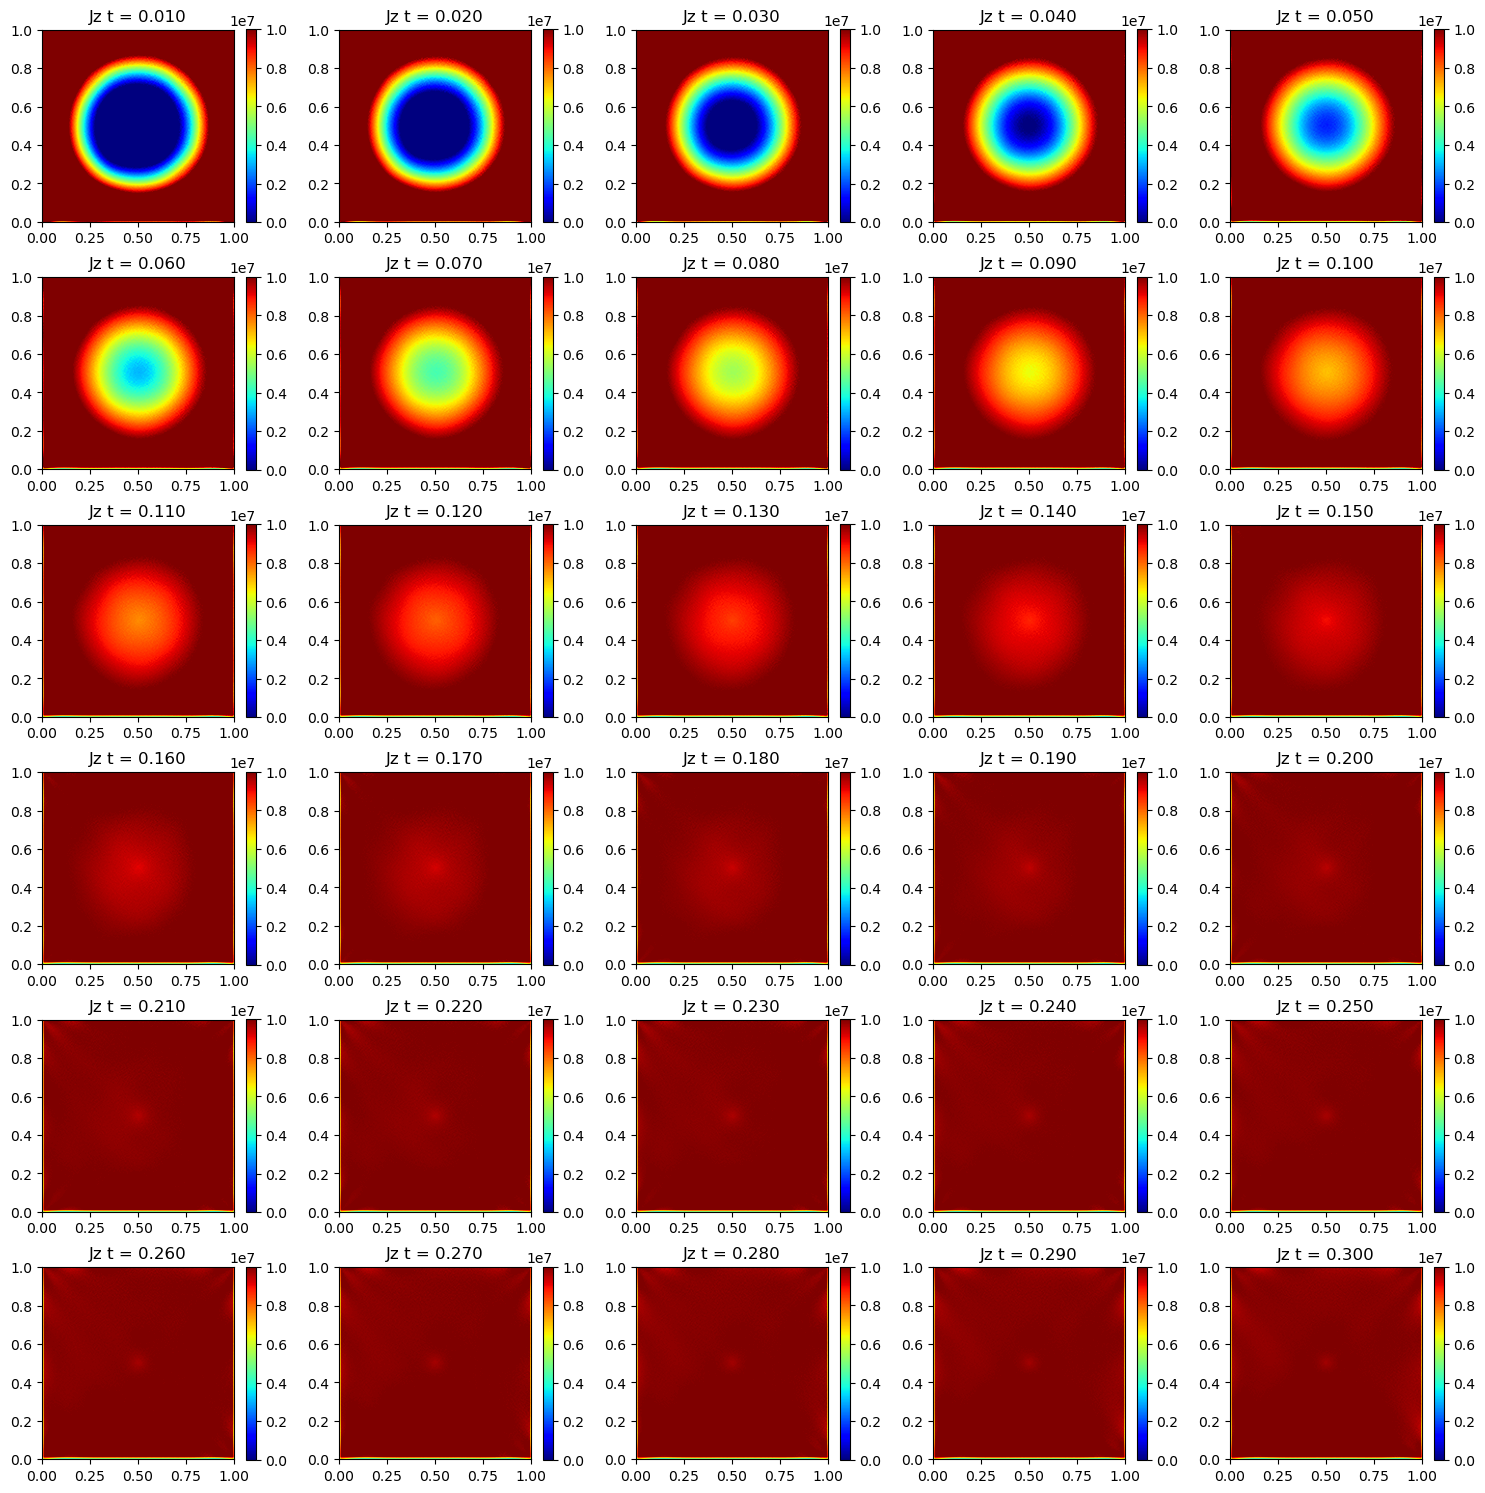

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

mu_0 = 4 * np.pi * 1e-7  # Permeability of free space (H/m)
mu = 1  # Relative permeability (minimum)

# Compute second derivatives using finite differences with safe division
def compute_current_density(Az, y, x, nu):
    dy = np.ptp(y) / (len(y) - 1) if len(y) > 1 else 1  # ptp gives range
    dx = np.ptp(x) / (len(x) - 1) if len(x) > 1 else 1
    
    d2Az_dy2 = np.gradient(nu * np.gradient(Az, axis=1), axis=1) / (dy**2)
    d2Az_dz2 = np.gradient(nu * np.gradient(Az, axis=0), axis=0) / (dx**2)

    J = -(1/(mu*mu_0)) * (d2Az_dy2 + d2Az_dz2)
    return J

nu = 1/( 1-(b*B_mag) ) 
i = 0

current_densities = []
for Az_t in predictions:
    J_t = compute_current_density(Az_t, y, z, nu[i])
    current_densities.append(J_t)
    i += 1

vmin_J = np.min(current_densities)
vmax_J = np.max(current_densities)

fig, axes = plt.subplots(6, 5, figsize=(15, 15))
axes = axes.flatten()

for i, ax in enumerate(axes):
    im = ax.imshow(current_densities[i],vmin=0,vmax=1e7, extent=[y.min(), y.max(), z.min(), z.max()], origin='lower', cmap='jet') # vmin = vmin_J ,vmax = vmax_J,
    ax.set_title(f'Jz t = {time_intervals[i]:.3f}')
    fig.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# Save the relevant data to a .npz file
np.savez(file_name_J, time_intervals=time_intervals, z=z, y=y, predictions=current_densities)
